# Strategy Comparison Notebook

This notebook runs and compares:
1. **Baseline Strategies**: Long Only, Short Only, TSMOM
2. **LSTM Model**: Deep Momentum Network
3. **LSTM-GCN Model**: Graph-enhanced Deep Momentum Network

After each strategy, metrics are displayed including:
- E[Ret.], Vol., Sharpe, Sortino, Max Drawdown, Calmar, Hit Rate, Avg P/L Ratio
- Volatility-normalized returns (15% target)

## 1. Setup

In [4]:
# Mount Google Drive (for Colab)
from google.colab import drive
drive.mount('/content/drive')

import os
import sys

# Set working directory
# For Colab:
os.chdir('/content/drive/MyDrive/4YP-main')
# For local:
# os.chdir('/home/adam/new4YP/4YP-main')

sys.path.insert(0, os.getcwd())
print(f"Working directory: {os.getcwd()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Working directory: /content/drive/MyDrive/4YP-main


In [5]:
# Install dependencies if needed
!pip install -q tensorflow>=2.16.0 keras-tuner empyrical-reloaded

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from datetime import datetime

from empyrical import (
    sharpe_ratio,
    sortino_ratio,
    max_drawdown,
    annual_return,
    annual_volatility,
    calmar_ratio,
    downside_risk
)

# Set random seeds for reproducibility
import random
random.seed(42)
np.random.seed(42)

import tensorflow as tf
tf.random.set_seed(42)

print(f"TensorFlow version: {tf.__version__}")

TensorFlow version: 2.19.0


In [6]:
# Configuration
TRAIN_START = 2011
TEST_START = 2017
TEST_END = 2023
TEST_WINDOW_SIZE = 6  # years
NUM_REPEATS = 1

VOL_TARGET = 0.15  # 15% volatility target for normalization

print(f"Train: {TRAIN_START}-{TEST_START}")
print(f"Test:  {TEST_START}-{TEST_END}")

Train: 2011-2017
Test:  2017-2023


## 2. Helper Functions

In [7]:
def load_captured_returns(results_path):
    """Load captured returns from CSV file."""
    df = pd.read_csv(results_path)
    df['time'] = pd.to_datetime(df['time'])
    return df


def calc_daily_returns(df, returns_col='captured_returns'):
    """Aggregate daily returns across all tickers."""
    num_tickers = df['identifier'].nunique()
    daily_ret = df.groupby('time')[returns_col].sum() / num_tickers
    daily_ret.index = pd.to_datetime(daily_ret.index)
    return daily_ret.sort_index()


def calc_vol_scaled_returns(daily_returns, target_vol=0.15):
    """Scale returns to target annualized volatility."""
    current_vol = daily_returns.std() * np.sqrt(252)
    if current_vol > 0:
        scale_factor = target_vol / current_vol
        return daily_returns * scale_factor
    return daily_returns


def calc_metrics(daily_returns, name="Strategy"):
    """Calculate all performance metrics."""
    metrics = {
        'Strategy': name,
        'E[Ret.]': annual_return(daily_returns),
        'Vol.': annual_volatility(daily_returns),
        'Sharpe': sharpe_ratio(daily_returns),
        'Sortino': sortino_ratio(daily_returns),
        'Max DD': -max_drawdown(daily_returns),
        'Calmar': calmar_ratio(daily_returns),
        'Hit Rate': (daily_returns > 0).mean(),
        'Avg P/L': daily_returns[daily_returns > 0].mean() / abs(daily_returns[daily_returns < 0].mean()) if (daily_returns < 0).any() else np.nan,
    }
    return metrics


def calc_metrics_vol_normalized(daily_returns, name="Strategy", target_vol=0.15):
    """Calculate metrics with volatility-normalized returns."""
    scaled_returns = calc_vol_scaled_returns(daily_returns, target_vol)
    metrics = calc_metrics(scaled_returns, name + " (Vol-Norm)")
    return metrics, scaled_returns


def display_metrics(metrics_dict):
    """Display metrics in a formatted table."""
    df = pd.DataFrame([metrics_dict])
    df = df.set_index('Strategy')
    
    # Format percentages
    for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.2%}")
    
    # Format ratios
    for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
        if col in df.columns:
            df[col] = df[col].apply(lambda x: f"{x:.3f}")
    
    display(df)
    return df


def calc_yearly_sharpes(daily_returns):
    """Calculate Sharpe ratio by year."""
    yearly = {}
    for year in sorted(daily_returns.index.year.unique()):
        yr_ret = daily_returns[daily_returns.index.year == year]
        yearly[year] = sharpe_ratio(yr_ret)
    return yearly


def plot_results(daily_returns_dict, title="Strategy Comparison"):
    """Plot cumulative returns, drawdown, and rolling Sharpe for multiple strategies."""
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    colors = plt.cm.tab10(np.linspace(0, 1, len(daily_returns_dict)))
    
    # 1. Cumulative Returns
    ax1 = axes[0, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum_ret = (1 + returns).cumprod() - 1
        ax1.plot(cum_ret.index, cum_ret.values, label=name, linewidth=1.5, color=color)
    ax1.set_title('Cumulative Returns')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Cumulative Return')
    ax1.legend(loc='upper left', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # 2. Drawdown
    ax2 = axes[0, 1]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        cum = (1 + returns).cumprod()
        running_max = cum.cummax()
        drawdown = (cum - running_max) / running_max
        ax2.fill_between(drawdown.index, drawdown.values, 0, alpha=0.3, label=name, color=color)
    ax2.set_title('Drawdown')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Drawdown')
    ax2.legend(loc='lower left', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # 3. Rolling 252-day Sharpe
    ax3 = axes[1, 0]
    for (name, returns), color in zip(daily_returns_dict.items(), colors):
        rolling_sharpe = returns.rolling(252).mean() / returns.rolling(252).std() * np.sqrt(252)
        ax3.plot(rolling_sharpe.index, rolling_sharpe.values, label=name, linewidth=1, color=color)
    ax3.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax3.set_title('Rolling 252-Day Sharpe Ratio')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Sharpe Ratio')
    ax3.legend(loc='upper left', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # 4. Yearly Sharpe Comparison
    ax4 = axes[1, 1]
    yearly_data = {}
    for name, returns in daily_returns_dict.items():
        yearly_data[name] = calc_yearly_sharpes(returns)
    
    yearly_df = pd.DataFrame(yearly_data)
    yearly_df.plot(kind='bar', ax=ax4, width=0.8)
    ax4.axhline(y=0, color='black', linestyle='--', linewidth=0.5)
    ax4.set_title('Yearly Sharpe Ratios')
    ax4.set_xlabel('Year')
    ax4.set_ylabel('Sharpe Ratio')
    ax4.legend(loc='upper right', fontsize=8)
    ax4.tick_params(axis='x', rotation=45)
    ax4.grid(True, alpha=0.3, axis='y')
    
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('results/strategy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()


def plot_loss_curve(results_dir, title="Training Loss"):
    """Plot training loss curve if available."""
    loss_plot_path = os.path.join(results_dir, 'loss_plot.png')
    if os.path.exists(loss_plot_path):
        img = plt.imread(loss_plot_path)
        plt.figure(figsize=(10, 6))
        plt.imshow(img)
        plt.axis('off')
        plt.title(title)
        plt.show()
    else:
        print(f"Loss plot not found at: {loss_plot_path}")

In [8]:
# Store all results for final comparison
all_metrics = []
all_daily_returns = {}

---
## 3. LSTM-GCN Model (Graph Strategy)

Run the LSTM-GCN model first as it will be used as the reference for classical strategies.

In [13]:
from examples.run_graph_strategy import main as run_graph_main

print("="*60)
print("Running LSTM-GCN Model")
print("="*60)

run_graph_main(
    "LSTM-GCN",
    TRAIN_START,
    TEST_START,
    TEST_END,
    TEST_WINDOW_SIZE,
    NUM_REPEATS
)

Running LSTM-GCN Model
no lags


train _batch
After final stacking and culling:
inputs.shape: (57, 88, 20, 10)
outputs.shape: (57, 88, 20, 1)
active_entries.shape: (57, 88, 20, 1)
identifier.shape: (57, 88, 20, 1)
date.shape: (57, 88, 20, 1)


valid _batch
After final stacking and culling:
inputs.shape: (14, 88, 20, 10)
outputs.shape: (14, 88, 20, 1)
active_entries.shape: (14, 88, 20, 1)
identifier.shape: (14, 88, 20, 1)
date.shape: (14, 88, 20, 1)


test _batch
After final stacking and culling:
inputs.shape: (70, 88, 20, 10)
outputs.shape: (70, 88, 20, 1)
active_entries.shape: (70, 88, 20, 1)
identifier.shape: (70, 88, 20, 1)
date.shape: (70, 88, 20, 1)


test sliding _batch
After final stacking and culling:
inputs.shape: (1400, 88, 20, 10)
outputs.shape: (1400, 88, 20, 1)
active_entries.shape: (1400, 88, 20, 1)
identifier.shape: (1400, 88, 20, 1)
date.shape: (1400, 88, 20, 1)


Deep Momentum Network params:
architecture = LSTM-GCN
total_time_steps = 20
early_stopping_patience = 25
mu


LSTM-GCN Results (Raw)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN,5.21%,5.85%,0.897,1.237,9.66%,0.539,54.79%,0.977



Volatility-Normalized (Target: 15%)


,E[Ret.],Vol.,Sharpe,Sortino,Max DD,Calmar,Hit Rate,Avg P/L
Strategy,,,,,,,,
LSTM-GCN (Vol-Norm),13.12%,15.00%,0.897,1.237,23.50%,0.558,54.79%,0.977



Yearly Sharpe Ratios:
  2017: 2.2205
  2018: 0.4968
  2019: 1.4951
  2020: 0.7237
  2021: 1.1029
  2022: 0.0336




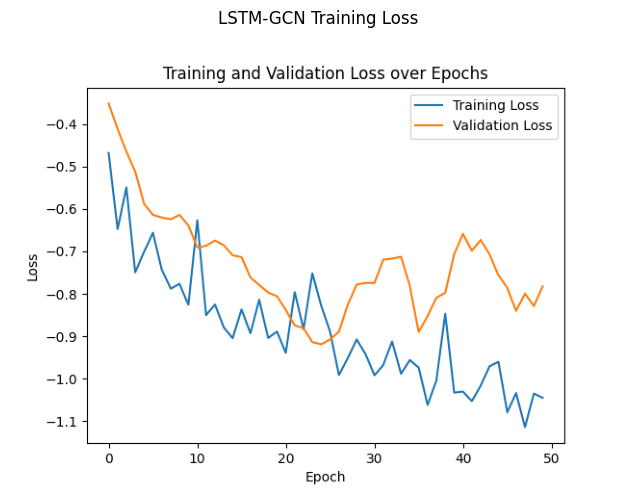

In [9]:
# Load LSTM-GCN results
LSTM_GCN_EXPERIMENT = "exp_lstm_gcn_split80_lstm-gcn_cpnone_len20_notime_val_v1"
lstm_gcn_results_dir = f"results/{LSTM_GCN_EXPERIMENT}/{TEST_START}-{TEST_END}"

lstm_gcn_csv = os.path.join(lstm_gcn_results_dir, "captured_returns_sw.csv")
if os.path.exists(lstm_gcn_csv):
    lstm_gcn_df = load_captured_returns(lstm_gcn_csv)
    lstm_gcn_returns = calc_daily_returns(lstm_gcn_df)
    
    # Raw metrics
    print("\n" + "="*60)
    print("LSTM-GCN Results (Raw)")
    print("="*60)
    metrics_raw = calc_metrics(lstm_gcn_returns, "LSTM-GCN")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['LSTM-GCN'] = lstm_gcn_returns
    
    # Vol-normalized metrics
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, scaled_returns = calc_metrics_vol_normalized(lstm_gcn_returns, "LSTM-GCN", VOL_TARGET)
    display_metrics(metrics_norm)
    
    # Yearly Sharpes
    print("\nYearly Sharpe Ratios:")
    yearly_sharpes = calc_yearly_sharpes(lstm_gcn_returns)
    for year, sharpe in yearly_sharpes.items():
        print(f"  {year}: {sharpe:.4f}")
    
    # Loss curve
    print("\n")
    plot_loss_curve(lstm_gcn_results_dir, "LSTM-GCN Training Loss")
else:
    print(f"Results not found at: {lstm_gcn_csv}")

---
## 4. LSTM Model (DNN Strategy)

In [11]:
from examples.run_dnn_strategy import main as run_dnn_main

print("="*60)
print("Running LSTM Model")
print("="*60)

run_dnn_main(
    "LSTM",
    TRAIN_START,
    TEST_START,
    TEST_END,
    TEST_WINDOW_SIZE,
    NUM_REPEATS
)

SyntaxError: invalid syntax (graph_model_2.py, line 187)

In [ ]:
  filepath = '/content/drive/MyDrive/4YP-main/gml/graph_model_2.py'

  with open(filepath, 'r') as f:
      content = f.read()

  # Fix double return
  content = content.replace('return return super', 'return super')

  with open(filepath, 'w') as f:
      f.write(content)

  print("Fixed double return. Restart runtime.")

In [27]:
filepath = '/content/drive/MyDrive/4YP-main/gml/deep_neural_network.py'

with open(filepath, 'r') as f:
    content = f.read()

content = content.replace(
    'sample_weight_mode="temporal",',
    '#sample_weight_mode="temporal",  # Removed in Keras 3.x'
)

with open(filepath, 'w') as f:
    f.write(content)

print("Fixed sample_weight_mode for Keras 3.x compatibility")

Fixed sample_weight_mode for Keras 3.x compatibility


In [ ]:
# Load LSTM results
LSTM_EXPERIMENT = "exp_lstm_split60_lstm_cpnone_len20_notime_val_v1"
lstm_results_dir = f"results/{LSTM_EXPERIMENT}/{TEST_START}-{TEST_END}"

lstm_csv = os.path.join(lstm_results_dir, "captured_returns_sw.csv")
if os.path.exists(lstm_csv):
    lstm_df = load_captured_returns(lstm_csv)
    lstm_returns = calc_daily_returns(lstm_df)
    
    # Raw metrics
    print("\n" + "="*60)
    print("LSTM Results (Raw)")
    print("="*60)
    metrics_raw = calc_metrics(lstm_returns, "LSTM")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['LSTM'] = lstm_returns
    
    # Vol-normalized metrics
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, _ = calc_metrics_vol_normalized(lstm_returns, "LSTM", VOL_TARGET)
    display_metrics(metrics_norm)
    
    # Yearly Sharpes
    print("\nYearly Sharpe Ratios:")
    yearly_sharpes = calc_yearly_sharpes(lstm_returns)
    for year, sharpe in yearly_sharpes.items():
        print(f"  {year}: {sharpe:.4f}")
    
    # Loss curve
    print("\n")
    plot_loss_curve(lstm_results_dir, "LSTM Training Loss")
else:
    print(f"Results not found at: {lstm_csv}")

---
## 5. Classical Strategies (Baselines)

Run Long Only, Short Only, and TSMOM strategies using the LSTM-GCN results as reference.

In [ ]:
from gml.backtest import run_classical_methods
from settings.default import STRADDLE

print("="*60)
print("Running Classical Strategies (Baselines)")
print("="*60)

# Reference experiment (must have been run first)
REFERENCE_EXPERIMENT = LSTM_GCN_EXPERIMENT

# Features file
if STRADDLE:
    features_file_path = os.path.join("data", "straddle_features", "features.csv")
else:
    features_file_path = os.path.join("data", "equity_features", "features.csv")

# Intervals
INTERVALS = [(TRAIN_START, TEST_START, TEST_END)]

run_classical_methods(features_file_path, INTERVALS, REFERENCE_EXPERIMENT)

In [ ]:
# Load and display Long Only results
print("\n" + "="*60)
print("Long Only Results")
print("="*60)

long_only_csv = f"results/long_only/{TEST_START}-{TEST_END}/captured_returns_sw.csv"
if os.path.exists(long_only_csv):
    long_only_df = load_captured_returns(long_only_csv)
    long_only_returns = calc_daily_returns(long_only_df)
    
    metrics_raw = calc_metrics(long_only_returns, "Long Only")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['Long Only'] = long_only_returns
    
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, _ = calc_metrics_vol_normalized(long_only_returns, "Long Only", VOL_TARGET)
    display_metrics(metrics_norm)
else:
    print(f"Results not found at: {long_only_csv}")

In [ ]:
# Load and display Short Only results
print("\n" + "="*60)
print("Short Only Results")
print("="*60)

short_only_csv = f"results/short_only/{TEST_START}-{TEST_END}/captured_returns_sw.csv"
if os.path.exists(short_only_csv):
    short_only_df = load_captured_returns(short_only_csv)
    short_only_returns = calc_daily_returns(short_only_df)
    
    metrics_raw = calc_metrics(short_only_returns, "Short Only")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['Short Only'] = short_only_returns
    
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, _ = calc_metrics_vol_normalized(short_only_returns, "Short Only", VOL_TARGET)
    display_metrics(metrics_norm)
else:
    print(f"Results not found at: {short_only_csv}")

In [ ]:
# Load and display TSMOM results (momentum = 0, pure trend following)
print("\n" + "="*60)
print("TSMOM Results (Momentum = 0)")
print("="*60)

tsmom_csv = f"results/tsmom_0/{TEST_START}-{TEST_END}/captured_returns_sw.csv"
if os.path.exists(tsmom_csv):
    tsmom_df = load_captured_returns(tsmom_csv)
    tsmom_returns = calc_daily_returns(tsmom_df)
    
    metrics_raw = calc_metrics(tsmom_returns, "TSMOM (w=0)")
    display_metrics(metrics_raw)
    all_metrics.append(metrics_raw)
    all_daily_returns['TSMOM'] = tsmom_returns
    
    print(f"\nVolatility-Normalized (Target: {VOL_TARGET:.0%})")
    metrics_norm, _ = calc_metrics_vol_normalized(tsmom_returns, "TSMOM", VOL_TARGET)
    display_metrics(metrics_norm)
else:
    # Try alternative path
    tsmom_csv_alt = f"results/tsmom_0/{TEST_START}-{TEST_END}/captured_returns_raw.csv"
    if os.path.exists(tsmom_csv_alt):
        tsmom_df = pd.read_csv(tsmom_csv_alt)
        tsmom_df['time'] = pd.to_datetime(tsmom_df['time'])
        tsmom_returns = calc_daily_returns(tsmom_df)
        
        metrics_raw = calc_metrics(tsmom_returns, "TSMOM (w=0)")
        display_metrics(metrics_raw)
        all_metrics.append(metrics_raw)
        all_daily_returns['TSMOM'] = tsmom_returns
    else:
        print(f"Results not found at: {tsmom_csv}")

---
## 6. Final Comparison

In [ ]:
print("="*60)
print("FINAL COMPARISON - All Strategies")
print("="*60)

# Create comparison DataFrame
comparison_df = pd.DataFrame(all_metrics)
comparison_df = comparison_df.set_index('Strategy')

# Format for display
display_df = comparison_df.copy()
for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.2%}")
for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
    if col in display_df.columns:
        display_df[col] = display_df[col].apply(lambda x: f"{x:.3f}")

print("\nRaw Metrics:")
display(display_df)

In [ ]:
# Vol-normalized comparison
print(f"\nVolatility-Normalized Metrics (Target: {VOL_TARGET:.0%}):")

vol_norm_metrics = []
for name, returns in all_daily_returns.items():
    metrics, _ = calc_metrics_vol_normalized(returns, name, VOL_TARGET)
    metrics['Strategy'] = name  # Override the "(Vol-Norm)" suffix
    vol_norm_metrics.append(metrics)

vol_norm_df = pd.DataFrame(vol_norm_metrics)
vol_norm_df = vol_norm_df.set_index('Strategy')

# Format
display_vol_df = vol_norm_df.copy()
for col in ['E[Ret.]', 'Vol.', 'Max DD', 'Hit Rate']:
    if col in display_vol_df.columns:
        display_vol_df[col] = display_vol_df[col].apply(lambda x: f"{x:.2%}")
for col in ['Sharpe', 'Sortino', 'Calmar', 'Avg P/L']:
    if col in display_vol_df.columns:
        display_vol_df[col] = display_vol_df[col].apply(lambda x: f"{x:.3f}")

display(display_vol_df)

In [ ]:
# Plot all strategies
if all_daily_returns:
    plot_results(all_daily_returns, f"Strategy Comparison ({TEST_START}-{TEST_END})")

In [ ]:
# Yearly Sharpe comparison table
print("\nYearly Sharpe Ratios:")
yearly_sharpes_all = {}
for name, returns in all_daily_returns.items():
    yearly_sharpes_all[name] = calc_yearly_sharpes(returns)

yearly_df = pd.DataFrame(yearly_sharpes_all)
yearly_df = yearly_df.round(4)
yearly_df.loc['Average'] = yearly_df.mean()
display(yearly_df)

In [ ]:
# Save comparison to CSV
comparison_df.to_csv('results/strategy_comparison_metrics.csv')
vol_norm_df.to_csv('results/strategy_comparison_metrics_vol_normalized.csv')
yearly_df.to_csv('results/strategy_yearly_sharpes.csv')

print("\nResults saved to:")
print("  - results/strategy_comparison_metrics.csv")
print("  - results/strategy_comparison_metrics_vol_normalized.csv")
print("  - results/strategy_yearly_sharpes.csv")
print("  - results/strategy_comparison.png")

---
## 7. Summary

In [ ]:
print("="*60)
print("EXPERIMENT SUMMARY")
print("="*60)
print(f"\nTraining Period: {TRAIN_START} - {TEST_START}")
print(f"Test Period:     {TEST_START} - {TEST_END}")
print(f"\nStrategies Evaluated: {len(all_daily_returns)}")
for name in all_daily_returns.keys():
    print(f"  - {name}")

if all_metrics:
    best_sharpe = max(all_metrics, key=lambda x: x['Sharpe'])
    print(f"\nBest Sharpe Ratio: {best_sharpe['Strategy']} ({best_sharpe['Sharpe']:.3f})")
    
    best_return = max(all_metrics, key=lambda x: x['E[Ret.]'])
    print(f"Best Annual Return: {best_return['Strategy']} ({best_return['E[Ret.]']:.2%})")
    
    best_sortino = max(all_metrics, key=lambda x: x['Sortino'])
    print(f"Best Sortino Ratio: {best_sortino['Strategy']} ({best_sortino['Sortino']:.3f})")